In [1]:
import pandas as pd
import numpy as np

In [2]:
import pandas as pd

inv = pd.read_csv("../data/processed/inventory_clean.csv")
inv["date"] = pd.to_datetime(inv["date"])

latest_inv = inv.sort_values("date").groupby("sku_id").tail(1)
print(latest_inv.shape)
latest_inv.head()

(200, 6)


,date,sku_id,on_hand_units,on_order_units,lead_time_days,reorder_point
16928,2026-07-13,SKU0191,321.2,0.0,16.0,315.3
618,2026-07-13,SKU0007,95.6,0.0,14.0,70.0
1470,2026-07-13,SKU0017,103.6,0.0,12.0,67.8
12955,2026-07-13,SKU0146,322.4,0.0,22.0,260.7
12851,2026-07-13,SKU0145,242.1,0.0,12.0,185.8


In [3]:
horizon = pd.read_csv("../data/processed/horizon_forecast.csv")
horizon["week_start"] = pd.to_datetime(horizon["week_start"])

demand_summary = (
    horizon.groupby("sku_id")
    .agg(demand_8weeks=("predicted_demand", "sum"),
         is_low_confidence=("is_low_confidence", "first"))
    .reset_index()
)

weekly_sequences = (
    horizon.sort_values(["sku_id", "horizon_week"])
    .groupby("sku_id")["predicted_demand"]
    .apply(list)
    .to_dict()
)

print(demand_summary.shape)
demand_summary.head()

(200, 3)


,sku_id,demand_8weeks,is_low_confidence
0,SKU0001,142.000000,True
1,SKU0002,168.838489,False
2,SKU0003,549.275223,False
3,SKU0004,309.601088,False
4,SKU0005,368.010394,False


In [4]:
risk_data = demand_summary.merge(latest_inv, on="sku_id", how="left")
print(risk_data.shape)
risk_data.head()

(200, 8)


,sku_id,demand_8weeks,is_low_confidence,date,on_hand_units,on_order_units,lead_time_days,reorder_point
0,SKU0001,142.000000,True,2026-07-13,38.7,77.3,24.0,86.2
1,SKU0002,168.838489,False,2026-07-13,106.7,0.0,13.0,65.9
2,SKU0003,549.275223,False,2026-07-13,299.4,304.0,24.0,338.8
3,SKU0004,309.601088,False,2026-07-13,131.8,0.0,12.0,99.6
4,SKU0005,368.010394,False,2026-07-13,95.8,228.8,33.0,350.6


In [5]:
def demand_for_lead_time(sku_id, lead_time_days):
    weekly_vals = weekly_sequences[sku_id]
    daily_vals = [v / 7 for v in weekly_vals for _ in range(7)]
    days = min(int(round(lead_time_days)), len(daily_vals))
    return sum(daily_vals[:days])

risk_data["demand_over_lead_time"] = risk_data.apply(
    lambda row: demand_for_lead_time(row["sku_id"], row["lead_time_days"]), axis=1
)
risk_data["available_stock"] = risk_data["on_hand_units"] + risk_data["on_order_units"]
risk_data["stockout_risk_ratio"] = risk_data["demand_over_lead_time"] / risk_data["available_stock"].replace(0, np.nan)
risk_data["stockout_risk_ratio"] = risk_data["stockout_risk_ratio"].fillna(risk_data["demand_over_lead_time"].apply(lambda x: 1.0 if x > 0 else 0.0))

risk_data[["sku_id", "demand_8weeks", "lead_time_days", "demand_over_lead_time", "available_stock", "stockout_risk_ratio"]].head(10)

,sku_id,demand_8weeks,lead_time_days,demand_over_lead_time,available_stock,stockout_risk_ratio
0,SKU0001,142.000000,24.0,60.857143,116.0,0.524631
1,SKU0002,168.838489,13.0,41.170494,106.7,0.385853
2,SKU0003,549.275223,24.0,235.882099,603.4,0.390922
3,SKU0004,309.601088,12.0,66.458517,131.8,0.504238
4,SKU0005,368.010394,33.0,214.374177,324.6,0.660426
5,SKU0006,513.289208,7.0,53.620166,252.6,0.212273
6,SKU0007,156.923621,14.0,43.117909,95.6,0.451024
7,SKU0008,588.398135,22.0,227.728634,370.3,0.614984
8,SKU0009,356.711765,33.0,211.623438,376.9,0.561484
9,SKU0010,103.409087,8.0,13.538625,57.6,0.235046


In [6]:
risk_data["overstock_risk_ratio"] = risk_data["on_hand_units"] / risk_data["demand_8weeks"].replace(0, np.nan)
risk_data["overstock_risk_ratio"] = risk_data["overstock_risk_ratio"].fillna(risk_data["on_hand_units"].apply(lambda x: 1.0 if x > 0 else 0.0))

risk_data[["sku_id", "on_hand_units", "demand_8weeks", "overstock_risk_ratio"]].sort_values("overstock_risk_ratio", ascending=False).head(10)

,sku_id,on_hand_units,demand_8weeks,overstock_risk_ratio
198,SKU0199,70.0,86.667085,0.807688
65,SKU0066,73.9,93.168214,0.793189
163,SKU0164,85.5,108.797736,0.785862
20,SKU0021,269.3,346.613580,0.776946
191,SKU0192,154.2,202.939935,0.759831
194,SKU0195,1403.0,1849.245823,0.758688
124,SKU0125,154.9,204.691225,0.756750
184,SKU0185,52.4,71.560058,0.732252
128,SKU0129,24.4,33.326175,0.732157
150,SKU0151,516.5,712.526140,0.724886


In [7]:
risk_data["high_stockout_risk"] = risk_data["stockout_risk_ratio"] > 0.5
risk_data["high_overstock_risk"] = risk_data["overstock_risk_ratio"] > 0.5

def classify_risk(row):
    if row["high_stockout_risk"] and row["high_overstock_risk"]:
        return "Watch / Volatile"
    elif row["high_stockout_risk"]:
        return "Reorder Now"
    elif row["high_overstock_risk"]:
        return "Markdown / Clear"
    else:
        return "Healthy"

risk_data["risk_category"] = risk_data.apply(classify_risk, axis=1)

print(risk_data["risk_category"].value_counts())

risk_category
Healthy             82
Reorder Now         66
Markdown / Clear    38
Watch / Volatile    14
Name: count, dtype: int64


In [8]:
sku_clean = pd.read_csv("../data/processed/sku_master_clean.csv")
risk_data = risk_data.merge(sku_clean[["sku_id", "category", "subcategory", "unit_cost", "list_price"]], on="sku_id", how="left")

action_map = {
    "Reorder Now": "Raise a replenishment order before stock runs out.",
    "Markdown / Clear": "Promote or discount to free up capital.",
    "Watch / Volatile": "Investigate manually — demand is erratic.",
    "Healthy": "No action needed."
}
risk_data["recommended_action"] = risk_data["risk_category"].map(action_map)

risk_data["stockout_value_at_risk"] = np.where(
    risk_data["risk_category"].isin(["Reorder Now", "Watch / Volatile"]),
    (risk_data["demand_over_lead_time"] - 0.5 * risk_data["available_stock"]).clip(lower=0) * risk_data["list_price"],
    0
)

risk_data["overstock_capital_locked"] = np.where(
    risk_data["risk_category"].isin(["Markdown / Clear", "Watch / Volatile"]),
    (risk_data["on_hand_units"] - 0.5 * risk_data["demand_8weeks"]).clip(lower=0) * risk_data["unit_cost"],
    0
)

In [9]:
print("SKUs with nonzero stockout value at risk:", (risk_data["stockout_value_at_risk"] > 0).sum())
print("SKUs with nonzero overstock capital locked:", (risk_data["overstock_capital_locked"] > 0).sum())

print("\nTotal stockout value at risk: ₹", risk_data["stockout_value_at_risk"].sum())
print("Total overstock capital locked: ₹", risk_data["overstock_capital_locked"].sum())

SKUs with nonzero stockout value at risk: 80
SKUs with nonzero overstock capital locked: 52

Total stockout value at risk: ₹ 72641779.08900361
Total overstock capital locked: ₹ 10779461.930527886


In [10]:
import matplotlib.pyplot as plt

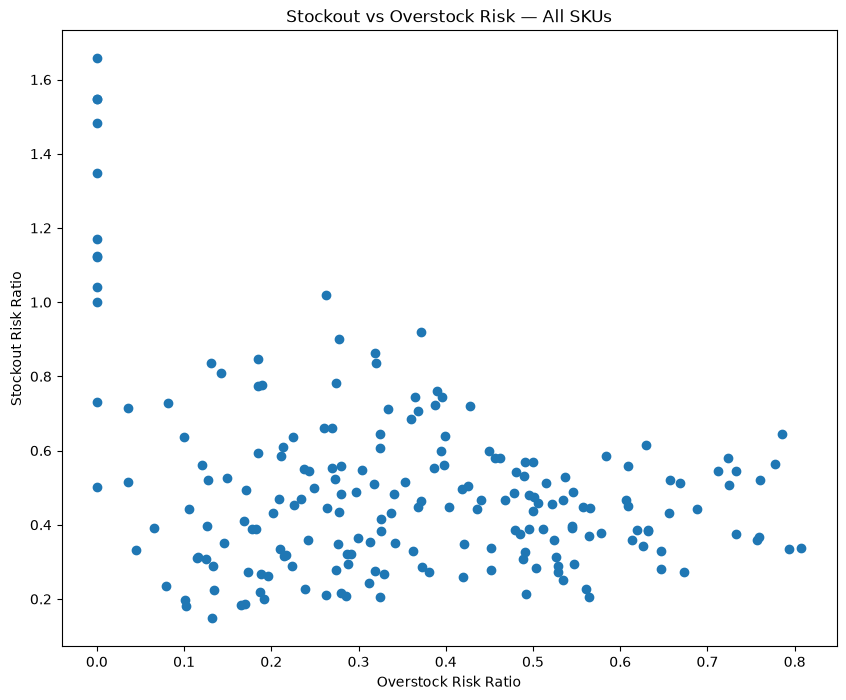

In [11]:
plt.figure(figsize=(10, 8))
plt.scatter(risk_data["overstock_risk_ratio"], risk_data["stockout_risk_ratio"])
plt.xlabel("Overstock Risk Ratio")
plt.ylabel("Stockout Risk Ratio")
plt.title("Stockout vs Overstock Risk — All SKUs")
plt.show()

In [12]:
zero_stock = risk_data[risk_data["on_hand_units"] == 0]
print("SKUs currently at zero stock:", len(zero_stock))
zero_stock[["sku_id", "on_hand_units", "stockout_risk_ratio", "risk_category"]]

SKUs currently at zero stock: 12


,sku_id,on_hand_units,stockout_risk_ratio,risk_category
15,SKU0016,0.0,1.122261,Reorder Now
28,SKU0029,0.0,1.349286,Reorder Now
50,SKU0051,0.0,1.125110,Reorder Now
51,SKU0052,0.0,1.039967,Reorder Now
66,SKU0067,0.0,1.170960,Reorder Now
70,SKU0071,0.0,0.730703,Reorder Now
77,SKU0078,0.0,0.502114,Reorder Now
102,SKU0103,0.0,0.999823,Reorder Now
108,SKU0109,0.0,1.483693,Reorder Now
139,SKU0140,0.0,1.656814,Reorder Now


In [13]:
risk_data[risk_data["sku_id"] == "SKU0078"][["sku_id", "on_hand_units", "on_order_units", "available_stock", "demand_over_lead_time", "stockout_risk_ratio"]]

,sku_id,on_hand_units,on_order_units,available_stock,demand_over_lead_time,stockout_risk_ratio
77,SKU0078,0.0,4.0,4.0,2.008454,0.502114


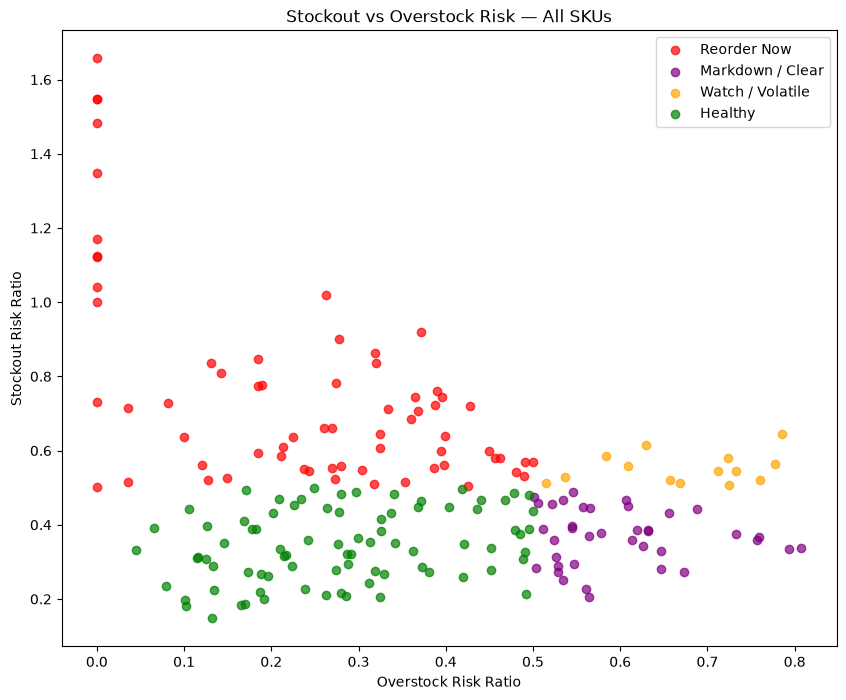

In [14]:
colors = {
    "Reorder Now": "red",
    "Markdown / Clear": "purple",
    "Watch / Volatile": "orange",
    "Healthy": "green"
}

plt.figure(figsize=(10, 8))
for category, color in colors.items():
    subset = risk_data[risk_data["risk_category"] == category]
    plt.scatter(subset["overstock_risk_ratio"], subset["stockout_risk_ratio"], 
                label=category, color=color, alpha=0.7)

plt.xlabel("Overstock Risk Ratio")
plt.ylabel("Stockout Risk Ratio")
plt.title("Stockout vs Overstock Risk — All SKUs")
plt.legend()
plt.savefig("../reports/figures/risk_decisioning_grid.png", bbox_inches="tight")
plt.show()

In [15]:
risk_data.to_csv("../data/processed/risk_scored.csv", index=False)
print("Saved:", risk_data.shape)

Saved: (200, 22)


In [16]:
print(risk_data[["sku_id", "category", "subcategory"]].head())

    sku_id          category     subcategory
0  SKU0001          Lighting  Ceiling Lights
1  SKU0002             Decor         Mirrors
2  SKU0003          Lighting     Table Lamps
3  SKU0004  Small Appliances   Coffee Makers
4  SKU0005       Furnishings          Tables
